# Enriched vs. Community Classification — Extended Analysis

Three experiments using different feature sets:

| # | Features | Age range | N (approx) |
|---|----------|-----------|------------|
| 1 | MDAT total score only | 0 – 6 yrs | ~4312 |
| 2 | DEEP total score only | 2.5 – 6 yrs | ~2296 |
| 3 | MDAT total + DEEP total + best START game | 2.5 – 6 yrs (intersect) | ~2627 |

The **best START game** for Experiment 3 is selected by training a Random Forest on all START features and computing mean importance per game prefix.

In [25]:
import pandas as pd
import numpy as np
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    roc_auc_score, precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Load Data

In [26]:
# ── Labels ──────────────────────────────────────────────────────────────────
bhisma = pd.read_csv('bhisma_data.csv', usecols=['id', 'sample'])
bhisma['child_ids'] = bhisma['id'] + '-BL'
bhisma['label'] = bhisma['sample'].map({'enriched': 1, 'community': 0})
bhisma = bhisma[bhisma['label'].notna()][['child_ids', 'label']]

# ── MDAT  (ages 0–6 years / 8–2191 days) ────────────────────────────────────
mdat = pd.read_csv('mdat_Deep_abilities.csv', usecols=['child_ids', 'tot'])
mdat.rename(columns={'tot': 'mdat_tot'}, inplace=True)

# ── DEEP  (ages 2.5–6 years) ─────────────────────────────────────────────────
deep = pd.read_csv('DEEP_Deep_abilities.csv', usecols=['child_ids', 'total_DEEP'])
deep.rename(columns={'total_DEEP': 'deep_tot'}, inplace=True)

# ── START (ages 2.5–6 years) ─────────────────────────────────────────────────
start = pd.read_csv('START.csv')
start_game_cols = [c for c in start.columns if c not in ['child_ids', 'Age']]

print(f'MDAT:   {len(mdat):,} records  |  tot NaN: {mdat.mdat_tot.isna().sum()}')
print(f'DEEP:   {len(deep):,} records  |  deep_tot NaN: {deep.deep_tot.isna().sum()}')
print(f'START:  {len(start):,} records  |  games: {sorted(set(c.split(".")[0] for c in start_game_cols))}')
print(f'Labels: {len(bhisma):,} children  ({bhisma.label.sum():.0f} enriched)')

MDAT:   4,312 records  |  tot NaN: 0
DEEP:   2,296 records  |  deep_tot NaN: 0
START:  3,994 records  |  games: ['bpt', 'bt', 'ct', 'dgt', 'mft', 'plt', 'st', 'wt']
Labels: 3,998 children  (259 enriched)


## Dataset Overview

                          N Enriched              Age range % Enriched
Exp 1  MDAT tot        4312      504                0–6 yrs      11.7%
Exp 2  DEEP tot        2296      152              2.5–6 yrs       6.6%
Exp 3  MDAT+DEEP+game  2627      399  2.5–6 yrs (intersect)      15.2%


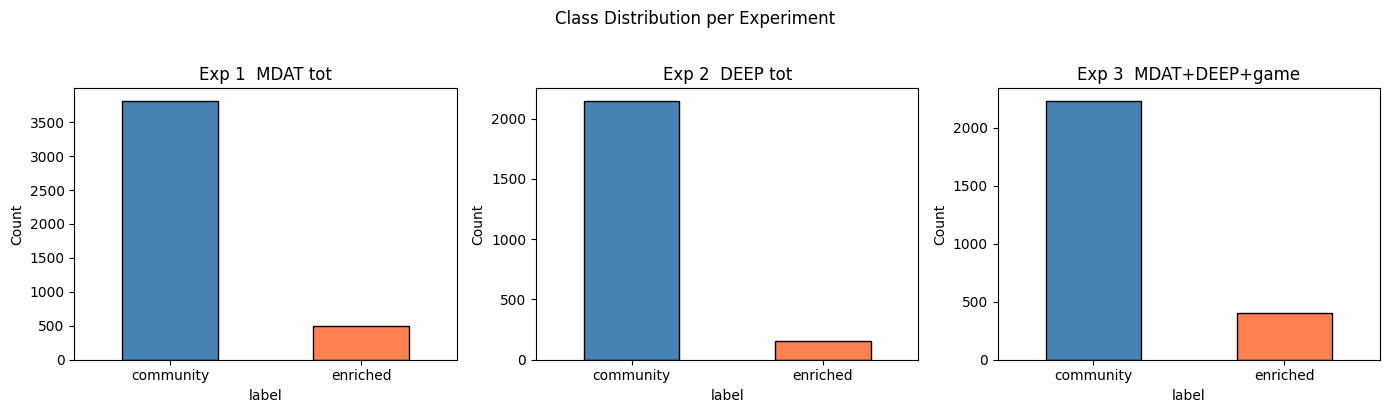

In [27]:
df1_raw = mdat.merge(bhisma, on='child_ids').dropna(subset=['mdat_tot'])
df2_raw = deep.merge(bhisma, on='child_ids').dropna(subset=['deep_tot'])
df3_raw = (mdat
           .merge(deep, on='child_ids')
           .merge(start[['child_ids'] + start_game_cols], on='child_ids')
           .merge(bhisma, on='child_ids'))

rows = {
    'Exp 1  MDAT tot':         {'N': len(df1_raw), 'Enriched': int(df1_raw.label.sum()), 'Age range': '0–6 yrs'},
    'Exp 2  DEEP tot':         {'N': len(df2_raw), 'Enriched': int(df2_raw.label.sum()), 'Age range': '2.5–6 yrs'},
    'Exp 3  MDAT+DEEP+game':   {'N': len(df3_raw), 'Enriched': int(df3_raw.label.sum()), 'Age range': '2.5–6 yrs (intersect)'},
}
info = pd.DataFrame(rows).T
info['% Enriched'] = (info['Enriched'].astype(float) / info['N'].astype(float) * 100).round(1).astype(str) + '%'
print(info.to_string())

# Bar chart of class balance per experiment
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, df_) in zip(axes, [
    ('Exp 1  MDAT tot', df1_raw),
    ('Exp 2  DEEP tot', df2_raw),
    ('Exp 3  MDAT+DEEP+game', df3_raw),
]):
    df_['label'].map({0: 'community', 1: 'enriched'}).value_counts().plot(
        kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black'
    )
    ax.set_title(name)
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylabel('Count')
plt.suptitle('Class Distribution per Experiment', y=1.02)
plt.tight_layout()
plt.show()

## Helper — `run_experiment`

Fits three classifiers (LR, RF, GB) each wrapped in a SMOTE pipeline, reports classification metrics, draws confusion matrices, and returns a summary DataFrame.

In [28]:
def run_experiment(df_in, feature_cols, exp_name):
    """
    Parameters
    ----------
    df_in        : DataFrame with feature_cols + 'label'
    feature_cols : list of feature column names to use
    exp_name     : string displayed in headers / plot titles

    Returns
    -------
    summary_df, fitted_pipes, X_test, y_test
    """
    df_model = df_in.dropna(subset=feature_cols).copy()
    X = df_model[feature_cols].copy()
    y = df_model['label'].copy().astype(int)

    print(f"\n{'='*62}")
    print(f"  {exp_name}")
    print(f"  Features : {feature_cols}")
    print(f"  N = {len(df_model):,}  |  Enriched = {y.sum()} ({y.mean()*100:.1f}%)")
    print(f"{'='*62}")

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    pipes = {
        'Logistic Regression': ImbPipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler()),
            ('smote',   SMOTE(random_state=42)),
            ('clf',     LogisticRegression(random_state=42, max_iter=1000, C=1.0)),
        ]),
        'Random Forest': ImbPipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('smote',   SMOTE(random_state=42)),
            ('clf',     RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
        ]),
        'Gradient Boosting': ImbPipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('smote',   SMOTE(random_state=42)),
            ('clf',     GradientBoostingClassifier(
                            n_estimators=200, learning_rate=0.05,
                            max_depth=3, random_state=42)),
        ]),
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fitted = {}
    rows = {}

    for name, pipe in pipes.items():
        pipe.fit(X_tr, y_tr)
        pred = pipe.predict(X_te)
        prob = pipe.predict_proba(X_te)[:, 1]
        cv_roc = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
        rep = classification_report(y_te, pred, output_dict=True)

        print(f"\n--- {name} ---")
        print(classification_report(y_te, pred, target_names=['community', 'enriched']))
        print(f"  ROC-AUC (test): {roc_auc_score(y_te, prob):.3f}  "
              f"| CV ROC-AUC: {cv_roc.mean():.3f} ± {cv_roc.std():.3f}")

        fitted[name] = pipe
        enr = rep.get('1', {})
        rows[name] = {
            'ROC-AUC (test)':     round(roc_auc_score(y_te, prob), 3),
            'CV ROC-AUC':         f"{cv_roc.mean():.3f} ± {cv_roc.std():.3f}",
            'Enriched Precision': round(enr.get('precision', float('nan')), 3),
            'Enriched Recall':    round(enr.get('recall',    float('nan')), 3),
            'Enriched F1':        round(enr.get('f1-score',  float('nan')), 3),
        }

    # Confusion matrices
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (name, pipe) in zip(axes, fitted.items()):
        pred = pipe.predict(X_te)
        auc  = roc_auc_score(y_te, pipe.predict_proba(X_te)[:, 1])
        ConfusionMatrixDisplay.from_predictions(
            y_te, pred, display_labels=['community', 'enriched'],
            ax=ax, cmap='Blues'
        )
        ax.set_title(f"{name}\nROC-AUC = {auc:.3f}")
    plt.suptitle(f"Confusion Matrices — {exp_name}", y=1.02)
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(rows).T, fitted, X_te, y_te


print('Helper loaded.')

Helper loaded.


## Best START Game Selection (for Experiment 3)

Fit a Random Forest on all START features (same SMOTE pipeline) and compute mean feature importance per game prefix. The top-ranked game's full feature set is used in Experiment 3.

Mean RF importance by START game:
dgt    0.130328
ct     0.100474
bpt    0.092313
mft    0.070215
bt     0.055331
plt    0.051465
wt     0.036925
st     0.033565

→ Best game : "dgt"
→ Features  : ['dgt.propDelay']


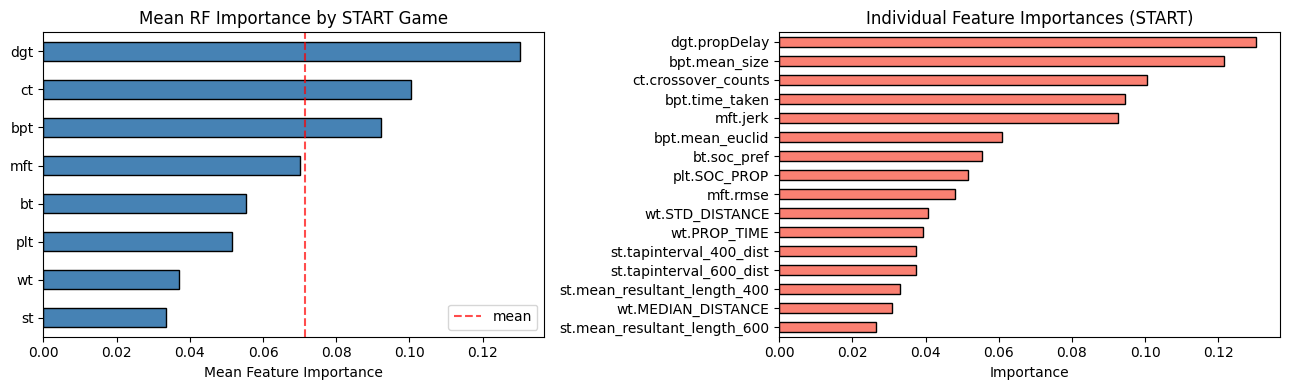

In [29]:
df_start = start[['child_ids'] + start_game_cols].merge(bhisma, on='child_ids')
df_start_model = df_start.dropna(subset=start_game_cols).copy()
X_start = df_start_model[start_game_cols]
y_start = df_start_model['label'].astype(int)

rf_start_pipe = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote',   SMOTE(random_state=42)),
    ('clf',     RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
])
rf_start_pipe.fit(X_start, y_start)

feat_imp = pd.Series(
    rf_start_pipe.named_steps['clf'].feature_importances_,
    index=start_game_cols
)

# Aggregate by game prefix
game_imp = feat_imp.groupby(feat_imp.index.map(lambda c: c.split('.')[0])).mean()
game_imp = game_imp.sort_values(ascending=False)

best_game        = game_imp.idxmax()
best_game_feats  = [c for c in start_game_cols if c.split('.')[0] == best_game]

print('Mean RF importance by START game:')
print(game_imp.to_string())
print(f'\n→ Best game : "{best_game}"')
print(f'→ Features  : {best_game_feats}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

game_imp.sort_values().plot(kind='barh', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('Mean RF Importance by START Game')
ax1.set_xlabel('Mean Feature Importance')
ax1.axvline(game_imp.mean(), color='red', linestyle='--', alpha=0.7, label='mean')
ax1.legend()

feat_imp.sort_values().plot(kind='barh', ax=ax2, color='salmon', edgecolor='black')
ax2.set_title('Individual Feature Importances (START)')
ax2.set_xlabel('Importance')

plt.tight_layout()
plt.show()

---
## Experiment 1 — MDAT Total Score Only

**Feature:** `mdat_tot`  
**Population:** All children with MDAT data (ages **0–6 years**).


  Experiment 1 — MDAT Total Score Only  (ages 0–6)
  Features : ['mdat_tot']
  N = 4,312  |  Enriched = 504 (11.7%)

--- Logistic Regression ---
              precision    recall  f1-score   support

   community       0.92      0.60      0.73       762
    enriched       0.17      0.60      0.26       101

    accuracy                           0.60       863
   macro avg       0.54      0.60      0.50       863
weighted avg       0.83      0.60      0.67       863

  ROC-AUC (test): 0.620  | CV ROC-AUC: 0.582 ± 0.016

--- Random Forest ---
              precision    recall  f1-score   support

   community       0.95      0.76      0.85       762
    enriched       0.29      0.71      0.41       101

    accuracy                           0.76       863
   macro avg       0.62      0.74      0.63       863
weighted avg       0.87      0.76      0.80       863

  ROC-AUC (test): 0.826  | CV ROC-AUC: 0.798 ± 0.023

--- Gradient Boosting ---
              precision    recall  f1-score 

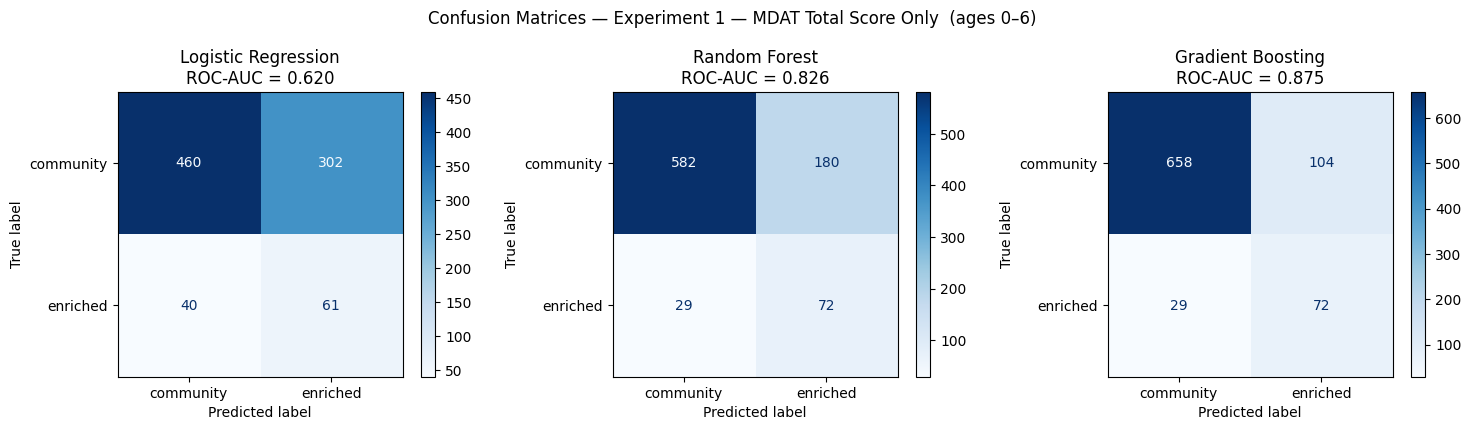


Summary:


,ROC-AUC (test),CV ROC-AUC,Enriched Precision,Enriched Recall,Enriched F1
Logistic Regression,0.62,0.582 ± 0.016,0.168,0.604,0.263
Random Forest,0.826,0.798 ± 0.023,0.286,0.713,0.408
Gradient Boosting,0.875,0.845 ± 0.018,0.409,0.713,0.52


In [30]:
df1 = mdat.merge(bhisma, on='child_ids')
feat1 = ['mdat_tot']

summary1, fitted1, Xte1, yte1 = run_experiment(
    df1, feat1,
    'Experiment 1 — MDAT Total Score Only  (ages 0–6)'
)
print('\nSummary:')
summary1

---
## Experiment 2 — DEEP Total Score Only

**Feature:** `deep_tot`  
**Population:** Children with DEEP data (ages **2.5–6 years**).


  Experiment 2 — DEEP Total Score Only  (ages 2.5–6)
  Features : ['deep_tot']
  N = 2,296  |  Enriched = 152 (6.6%)

--- Logistic Regression ---
              precision    recall  f1-score   support

   community       0.98      0.76      0.86       430
    enriched       0.19      0.80      0.31        30

    accuracy                           0.76       460
   macro avg       0.59      0.78      0.58       460
weighted avg       0.93      0.76      0.82       460

  ROC-AUC (test): 0.874  | CV ROC-AUC: 0.813 ± 0.032

--- Random Forest ---
              precision    recall  f1-score   support

   community       0.95      0.72      0.82       430
    enriched       0.11      0.50      0.18        30

    accuracy                           0.70       460
   macro avg       0.53      0.61      0.50       460
weighted avg       0.90      0.70      0.78       460

  ROC-AUC (test): 0.666  | CV ROC-AUC: 0.702 ± 0.054

--- Gradient Boosting ---
              precision    recall  f1-score

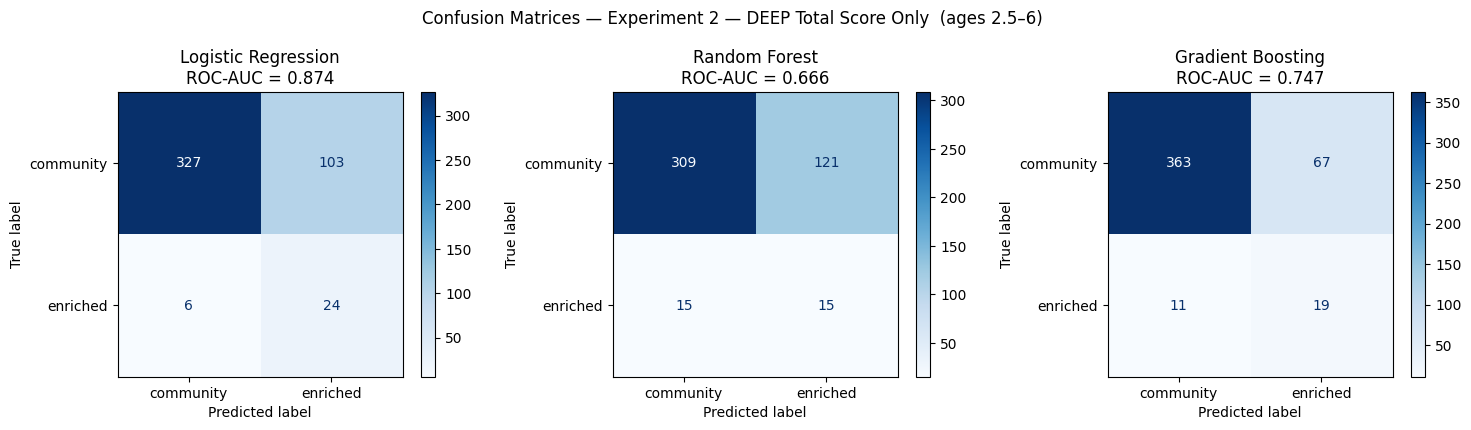


Summary:


,ROC-AUC (test),CV ROC-AUC,Enriched Precision,Enriched Recall,Enriched F1
Logistic Regression,0.874,0.813 ± 0.032,0.189,0.8,0.306
Random Forest,0.666,0.702 ± 0.054,0.11,0.5,0.181
Gradient Boosting,0.747,0.772 ± 0.047,0.221,0.633,0.328


In [31]:
df2 = deep.merge(bhisma, on='child_ids')
feat2 = ['deep_tot']

summary2, fitted2, Xte2, yte2 = run_experiment(
    df2, feat2,
    'Experiment 2 — DEEP Total Score Only  (ages 2.5–6)'
)
print('\nSummary:')
summary2

---
## Experiment 3 — MDAT Total + DEEP Total + Best START Game

**Features:** `mdat_tot`, `deep_tot`, all features of the top-ranked START game  
**Population:** Children present in all three datasets (ages **2.5–6 years**, intersect).

Features used: ['mdat_tot', 'deep_tot', 'dgt.propDelay']

  Experiment 3 — MDAT + DEEP + "dgt" game  (ages 2.5–6 intersect)
  Features : ['mdat_tot', 'deep_tot', 'dgt.propDelay']
  N = 2,587  |  Enriched = 390 (15.1%)

--- Logistic Regression ---
              precision    recall  f1-score   support

   community       0.92      0.73      0.81       440
    enriched       0.29      0.63      0.40        78

    accuracy                           0.71       518
   macro avg       0.60      0.68      0.60       518
weighted avg       0.82      0.71      0.75       518

  ROC-AUC (test): 0.800  | CV ROC-AUC: 0.818 ± 0.029

--- Random Forest ---
              precision    recall  f1-score   support

   community       0.97      0.95      0.96       440
    enriched       0.76      0.82      0.79        78

    accuracy                           0.93       518
   macro avg       0.86      0.89      0.88       518
weighted avg       0.94      0.93      0.94       518

  ROC-AUC (test): 0.928

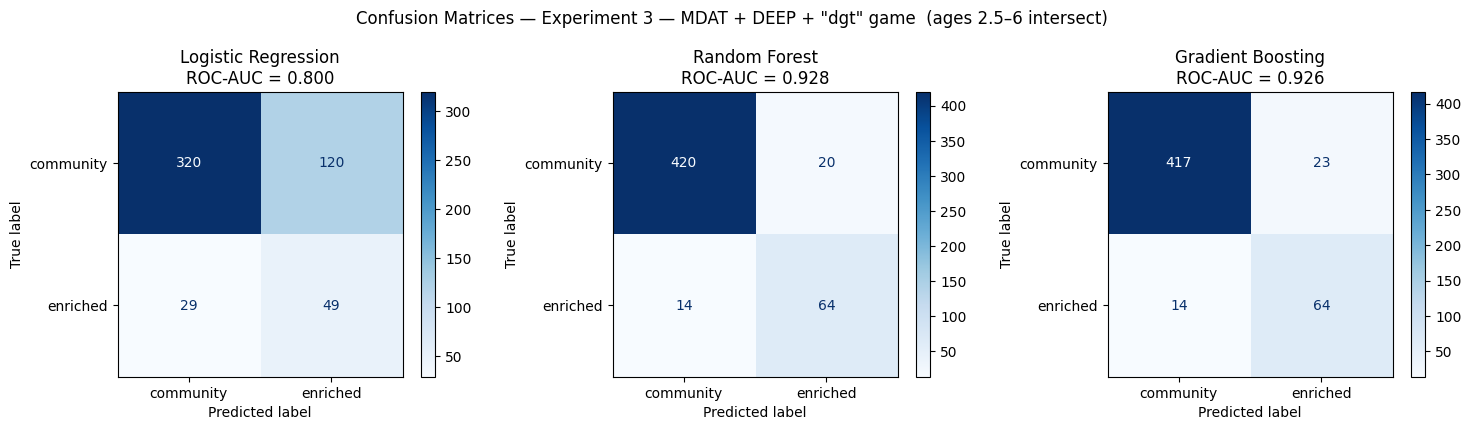


Summary:


,ROC-AUC (test),CV ROC-AUC,Enriched Precision,Enriched Recall,Enriched F1
Logistic Regression,0.8,0.818 ± 0.029,0.29,0.628,0.397
Random Forest,0.928,0.962 ± 0.020,0.762,0.821,0.79
Gradient Boosting,0.926,0.959 ± 0.025,0.736,0.821,0.776


In [32]:
df3 = (
    mdat
    .merge(deep, on='child_ids')
    .merge(start[['child_ids'] + best_game_feats], on='child_ids')
    .merge(bhisma, on='child_ids')
)

feat3 = ['mdat_tot', 'deep_tot'] + best_game_feats
print(f'Features used: {feat3}')

summary3, fitted3, Xte3, yte3 = run_experiment(
    df3, feat3,
    f'Experiment 3 — MDAT + DEEP + "{best_game}" game  (ages 2.5–6 intersect)'
)
print('\nSummary:')
summary3

---
## Experiment 4 — MDAT Total + DEEP Total (no START)

**Features:** `mdat_tot`, `deep_tot`  \
**Purpose:** isolate how much START contributes when combined with MDAT + DEEP.  \
**Population:** 2.5–6 yrs (MDAT ∩ DEEP).


  Experiment 4 — MDAT + DEEP only  (no START)
  Features : ['mdat_tot', 'deep_tot']
  N = 2,627  |  Enriched = 399 (15.2%)

--- Logistic Regression ---
              precision    recall  f1-score   support

   community       0.92      0.74      0.82       446
    enriched       0.30      0.62      0.41        80

    accuracy                           0.72       526
   macro avg       0.61      0.68      0.61       526
weighted avg       0.82      0.72      0.76       526

  ROC-AUC (test): 0.794  | CV ROC-AUC: 0.820 ± 0.033

--- Random Forest ---
              precision    recall  f1-score   support

   community       0.98      0.93      0.95       446
    enriched       0.68      0.89      0.77        80

    accuracy                           0.92       526
   macro avg       0.83      0.91      0.86       526
weighted avg       0.93      0.92      0.92       526

  ROC-AUC (test): 0.948  | CV ROC-AUC: 0.943 ± 0.022

--- Gradient Boosting ---
              precision    recall  f1

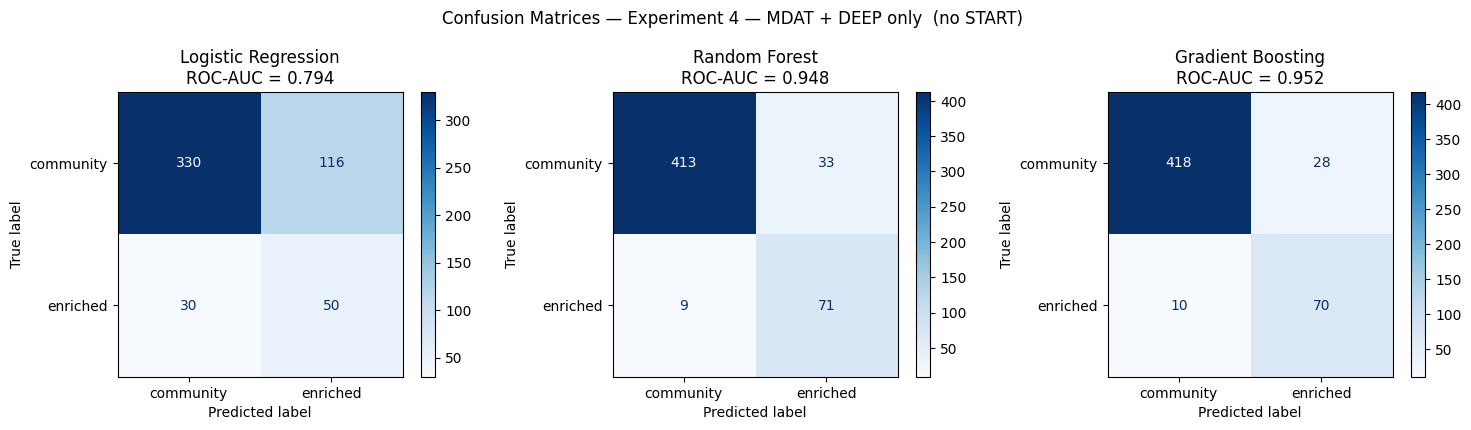


Summary:


,ROC-AUC (test),CV ROC-AUC,Enriched Precision,Enriched Recall,Enriched F1
Logistic Regression,0.794,0.820 ± 0.033,0.301,0.625,0.407
Random Forest,0.948,0.943 ± 0.022,0.683,0.887,0.772
Gradient Boosting,0.952,0.947 ± 0.010,0.714,0.875,0.787


In [33]:
df4 = mdat.merge(deep, on='child_ids').merge(bhisma, on='child_ids')
feat4 = ['mdat_tot', 'deep_tot']

summary4, fitted4, Xte4, yte4 = run_experiment(
    df4, feat4,
    'Experiment 4 — MDAT + DEEP only  (no START)'
)
print('\nSummary:')
summary4

---
## Experiment 5 — MDAT + DEEP + `bt` Game

**Features:** `mdat_tot`, `deep_tot`, `bt.soc_pref`  \
**Population:** 2.5–6 yrs (MDAT ∩ DEEP ∩ START).

Features: ['mdat_tot', 'deep_tot', 'bt.soc_pref']

  Experiment 5 — MDAT + DEEP + "bt"  (bt.soc_pref)
  Features : ['mdat_tot', 'deep_tot', 'bt.soc_pref']
  N = 2,514  |  Enriched = 291 (11.6%)

--- Logistic Regression ---
              precision    recall  f1-score   support

   community       0.95      0.70      0.80       445
    enriched       0.23      0.71      0.35        58

    accuracy                           0.70       503
   macro avg       0.59      0.70      0.58       503
weighted avg       0.87      0.70      0.75       503

  ROC-AUC (test): 0.818  | CV ROC-AUC: 0.779 ± 0.031

--- Random Forest ---
              precision    recall  f1-score   support

   community       0.97      0.94      0.96       445
    enriched       0.63      0.78      0.70        58

    accuracy                           0.92       503
   macro avg       0.80      0.86      0.83       503
weighted avg       0.93      0.92      0.93       503

  ROC-AUC (test): 0.945  | CV ROC-AUC: 0.935 ± 

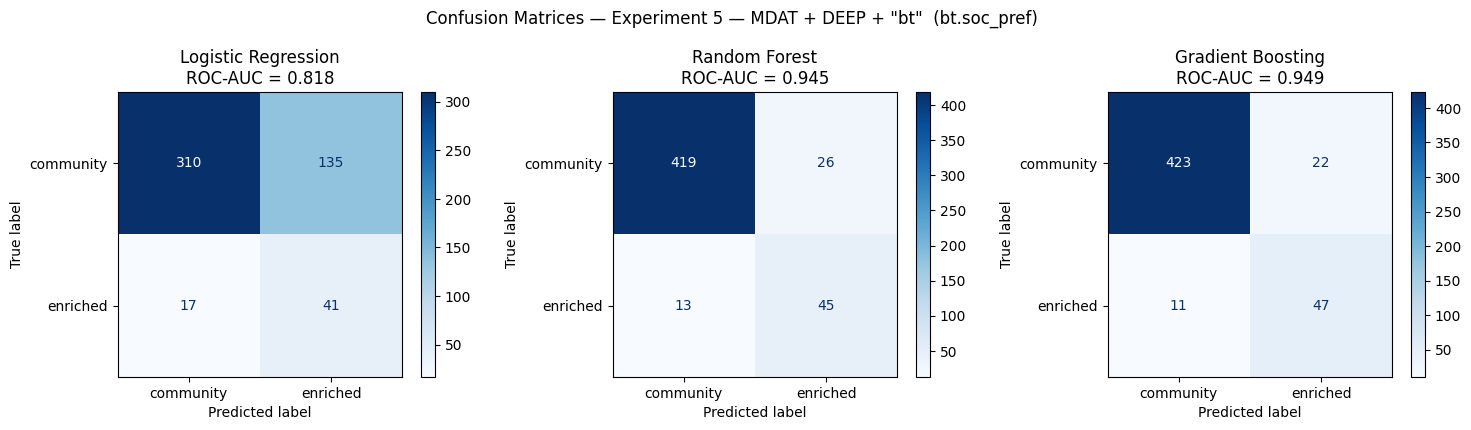


Summary:


,ROC-AUC (test),CV ROC-AUC,Enriched Precision,Enriched Recall,Enriched F1
Logistic Regression,0.818,0.779 ± 0.031,0.233,0.707,0.35
Random Forest,0.945,0.935 ± 0.016,0.634,0.776,0.698
Gradient Boosting,0.949,0.930 ± 0.016,0.681,0.81,0.74


In [34]:
bt_feats  = [c for c in start_game_cols if c.split('.')[0] == 'bt']
df5 = (mdat.merge(deep, on='child_ids')
           .merge(start[['child_ids'] + bt_feats], on='child_ids')
           .merge(bhisma, on='child_ids'))
feat5 = ['mdat_tot', 'deep_tot'] + bt_feats
print(f'Features: {feat5}')

summary5, fitted5, Xte5, yte5 = run_experiment(
    df5, feat5,
    'Experiment 5 — MDAT + DEEP + "bt"  (bt.soc_pref)'
)
print('\nSummary:')
summary5

---
## Experiment 6 — MDAT + DEEP + `wt` Game

**Features:** `mdat_tot`, `deep_tot`, `wt.PROP_TIME`, `wt.MEDIAN_DISTANCE`, `wt.STD_DISTANCE`  \
**Population:** 2.5–6 yrs (MDAT ∩ DEEP ∩ START).

Features: ['mdat_tot', 'deep_tot', 'wt.PROP_TIME', 'wt.MEDIAN_DISTANCE', 'wt.STD_DISTANCE']

  Experiment 6 — MDAT + DEEP + "wt"  (wt.PROP_TIME / wt.MEDIAN_DISTANCE / wt.STD_DISTANCE)
  Features : ['mdat_tot', 'deep_tot', 'wt.PROP_TIME', 'wt.MEDIAN_DISTANCE', 'wt.STD_DISTANCE']
  N = 2,525  |  Enriched = 336 (13.3%)

--- Logistic Regression ---
              precision    recall  f1-score   support

   community       0.93      0.71      0.81       438
    enriched       0.26      0.66      0.37        67

    accuracy                           0.71       505
   macro avg       0.60      0.69      0.59       505
weighted avg       0.84      0.71      0.75       505

  ROC-AUC (test): 0.768  | CV ROC-AUC: 0.798 ± 0.019

--- Random Forest ---
              precision    recall  f1-score   support

   community       0.98      0.97      0.98       438
    enriched       0.84      0.85      0.84        67

    accuracy                           0.96       505
   macro avg       0.91      0.9

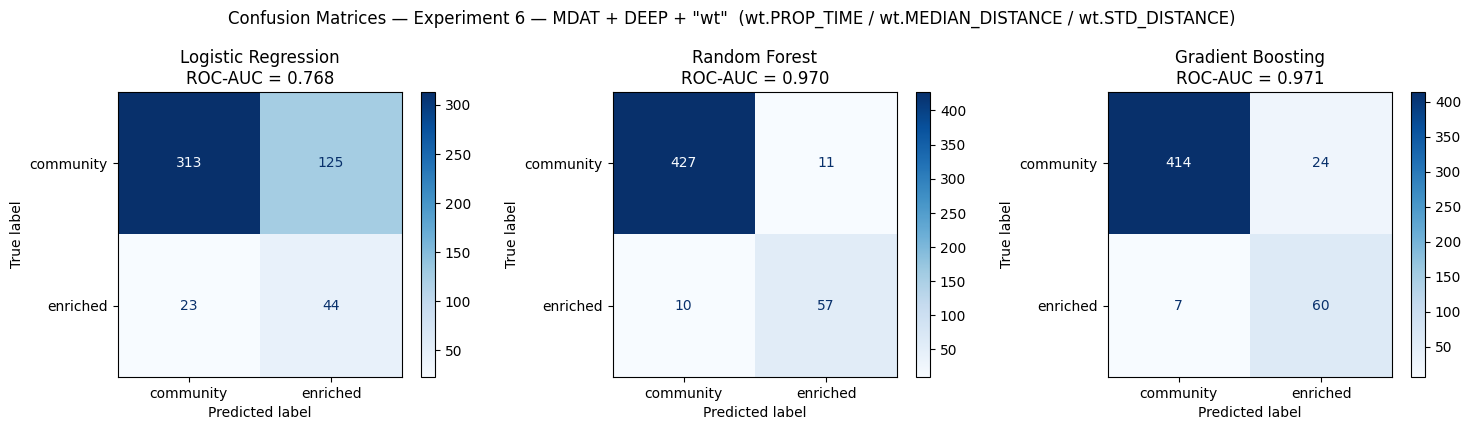


Summary:


,ROC-AUC (test),CV ROC-AUC,Enriched Precision,Enriched Recall,Enriched F1
Logistic Regression,0.768,0.798 ± 0.019,0.26,0.657,0.373
Random Forest,0.97,0.943 ± 0.019,0.838,0.851,0.844
Gradient Boosting,0.971,0.942 ± 0.024,0.714,0.896,0.795


In [35]:
wt_feats  = [c for c in start_game_cols if c.split('.')[0] == 'wt']
df6 = (mdat.merge(deep, on='child_ids')
           .merge(start[['child_ids'] + wt_feats], on='child_ids')
           .merge(bhisma, on='child_ids'))
feat6 = ['mdat_tot', 'deep_tot'] + wt_feats
print(f'Features: {feat6}')

summary6, fitted6, Xte6, yte6 = run_experiment(
    df6, feat6,
    'Experiment 6 — MDAT + DEEP + "wt"  (wt.PROP_TIME / wt.MEDIAN_DISTANCE / wt.STD_DISTANCE)'
)
print('\nSummary:')
summary6

---
## Experiment 7 — MDAT + DEEP + `bpt` Game

**Features:** `mdat_tot`, `deep_tot`, `bpt.mean_size`, `bpt.mean_euclid`, `bpt.time_taken`  \
**Population:** 2.5–6 yrs (MDAT ∩ DEEP ∩ START).

Features: ['mdat_tot', 'deep_tot', 'bpt.mean_size', 'bpt.mean_euclid', 'bpt.time_taken']

  Experiment 7 — MDAT + DEEP + "bpt"  (bpt.mean_size / bpt.mean_euclid / bpt.time_taken)
  Features : ['mdat_tot', 'deep_tot', 'bpt.mean_size', 'bpt.mean_euclid', 'bpt.time_taken']
  N = 2,611  |  Enriched = 388 (14.9%)

--- Logistic Regression ---
              precision    recall  f1-score   support

   community       0.96      0.79      0.87       445
    enriched       0.41      0.83      0.55        78

    accuracy                           0.80       523
   macro avg       0.69      0.81      0.71       523
weighted avg       0.88      0.80      0.82       523

  ROC-AUC (test): 0.850  | CV ROC-AUC: 0.850 ± 0.035

--- Random Forest ---
              precision    recall  f1-score   support

   community       0.97      0.97      0.97       445
    enriched       0.82      0.82      0.82        78

    accuracy                           0.95       523
   macro avg       0.89      0.89      0

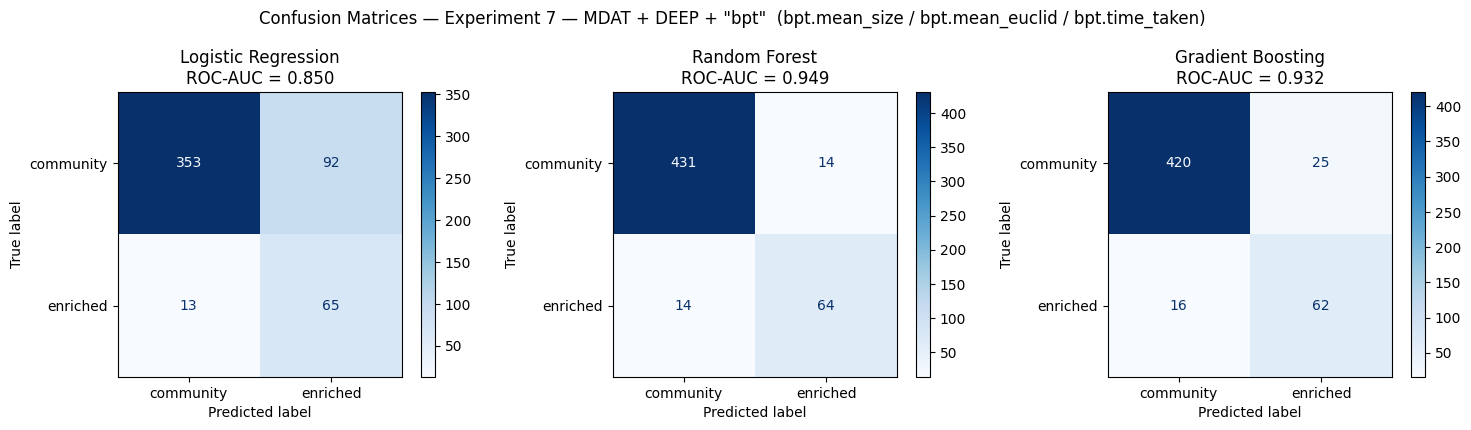


Summary:


,ROC-AUC (test),CV ROC-AUC,Enriched Precision,Enriched Recall,Enriched F1
Logistic Regression,0.85,0.850 ± 0.035,0.414,0.833,0.553
Random Forest,0.949,0.957 ± 0.016,0.821,0.821,0.821
Gradient Boosting,0.932,0.949 ± 0.026,0.713,0.795,0.752


In [36]:
bpt_feats = [c for c in start_game_cols if c.split('.')[0] == 'bpt']
df7 = (mdat.merge(deep, on='child_ids')
           .merge(start[['child_ids'] + bpt_feats], on='child_ids')
           .merge(bhisma, on='child_ids'))
feat7 = ['mdat_tot', 'deep_tot'] + bpt_feats
print(f'Features: {feat7}')

summary7, fitted7, Xte7, yte7 = run_experiment(
    df7, feat7,
    'Experiment 7 — MDAT + DEEP + "bpt"  (bpt.mean_size / bpt.mean_euclid / bpt.time_taken)'
)
print('\nSummary:')
summary7

---
## Experiment 8 — `dgt` Only

**Features:** `dgt.propDelay`  \
**Population:** children with dgt data (ages 2.5–6).

Features: ['dgt.propDelay']

  Experiment 8 — dgt Only  (dgt.propDelay)
  Features : ['dgt.propDelay']
  N = 2,280  |  Enriched = 156 (6.8%)

--- Logistic Regression ---
              precision    recall  f1-score   support

   community       0.92      0.54      0.68       425
    enriched       0.05      0.35      0.09        31

    accuracy                           0.53       456
   macro avg       0.49      0.45      0.39       456
weighted avg       0.86      0.53      0.64       456

  ROC-AUC (test): 0.436  | CV ROC-AUC: 0.508 ± 0.027

--- Random Forest ---
              precision    recall  f1-score   support

   community       0.97      0.30      0.46       425
    enriched       0.08      0.87      0.15        31

    accuracy                           0.34       456
   macro avg       0.53      0.59      0.31       456
weighted avg       0.91      0.34      0.44       456

  ROC-AUC (test): 0.564  | CV ROC-AUC: 0.506 ± 0.026

--- Gradient Boosting ---
              precis

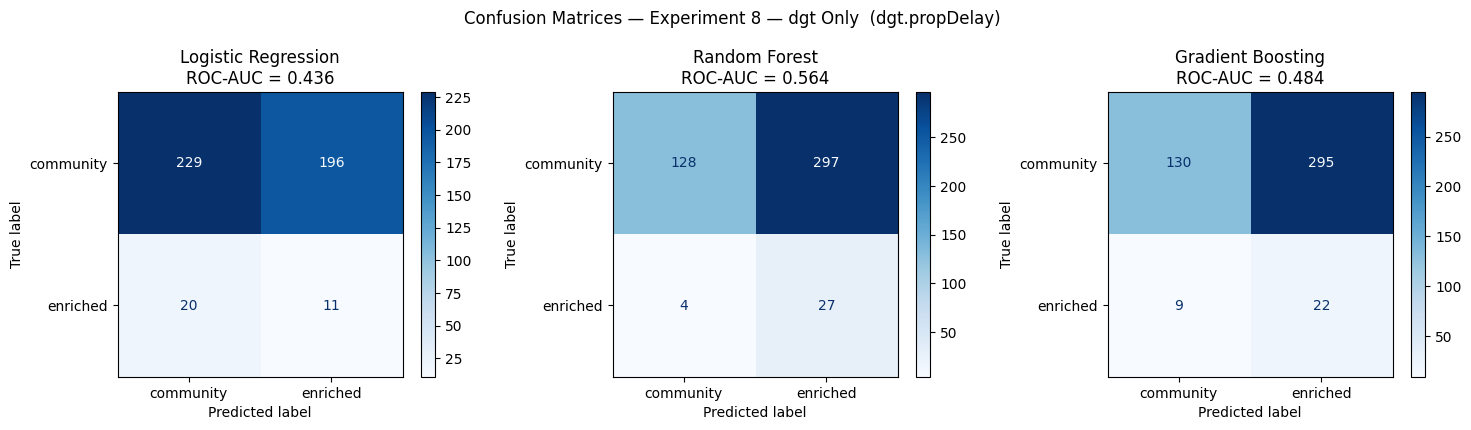


Summary:


,ROC-AUC (test),CV ROC-AUC,Enriched Precision,Enriched Recall,Enriched F1
Logistic Regression,0.436,0.508 ± 0.027,0.053,0.355,0.092
Random Forest,0.564,0.506 ± 0.026,0.083,0.871,0.152
Gradient Boosting,0.484,0.519 ± 0.041,0.069,0.71,0.126


In [37]:
dgt_feats = [c for c in start_game_cols if c.split('.')[0] == 'dgt']
df8 = start[['child_ids'] + dgt_feats].merge(bhisma, on='child_ids')
feat8 = dgt_feats
print(f'Features: {feat8}')
summary8, fitted8, Xte8, yte8 = run_experiment(df8, feat8, 'Experiment 8 — dgt Only  (dgt.propDelay)')
print('\nSummary:')
summary8

---
## Experiment 9 — `wt` Only

**Features:** `wt.PROP_TIME`, `wt.MEDIAN_DISTANCE`, `wt.STD_DISTANCE`  \
**Population:** children with wt data (ages 2.5–6).

Features: ['wt.PROP_TIME', 'wt.MEDIAN_DISTANCE', 'wt.STD_DISTANCE']

  Experiment 9 — wt Only  (wt.PROP_TIME / wt.MEDIAN_DISTANCE / wt.STD_DISTANCE)
  Features : ['wt.PROP_TIME', 'wt.MEDIAN_DISTANCE', 'wt.STD_DISTANCE']
  N = 2,251  |  Enriched = 132 (5.9%)

--- Logistic Regression ---
              precision    recall  f1-score   support

   community       0.98      0.69      0.81       425
    enriched       0.12      0.73      0.21        26

    accuracy                           0.69       451
   macro avg       0.55      0.71      0.51       451
weighted avg       0.93      0.69      0.77       451

  ROC-AUC (test): 0.790  | CV ROC-AUC: 0.728 ± 0.048

--- Random Forest ---
              precision    recall  f1-score   support

   community       0.96      0.85      0.90       425
    enriched       0.15      0.42      0.22        26

    accuracy                           0.83       451
   macro avg       0.56      0.64      0.56       451
weighted avg       0.91      0.83     

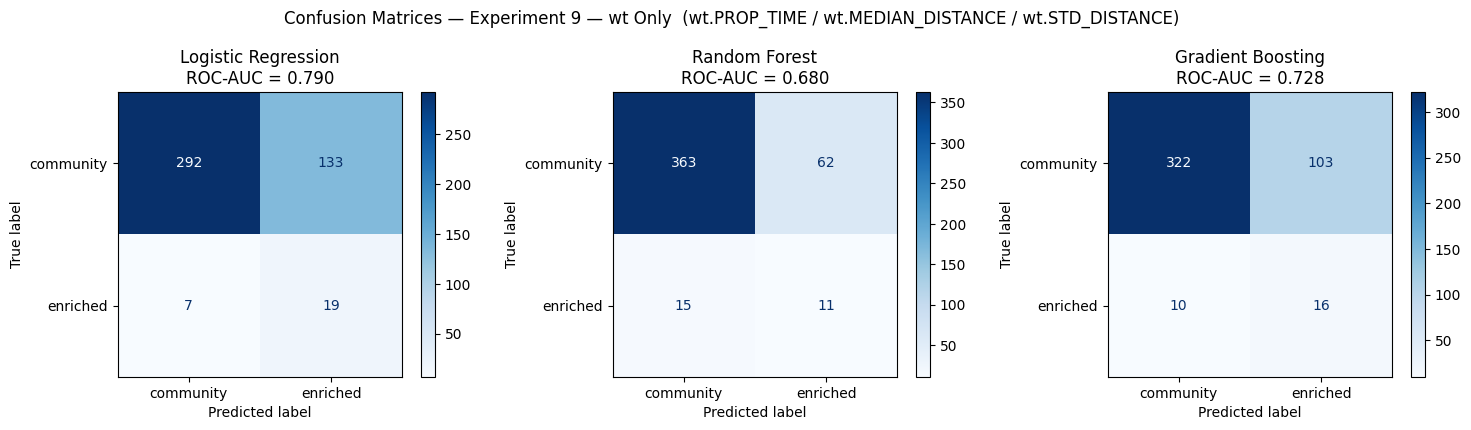


Summary:


,ROC-AUC (test),CV ROC-AUC,Enriched Precision,Enriched Recall,Enriched F1
Logistic Regression,0.79,0.728 ± 0.048,0.125,0.731,0.213
Random Forest,0.68,0.617 ± 0.064,0.151,0.423,0.222
Gradient Boosting,0.728,0.650 ± 0.071,0.134,0.615,0.221


In [38]:
wt_feats = [c for c in start_game_cols if c.split('.')[0] == 'wt']
df9 = start[['child_ids'] + wt_feats].merge(bhisma, on='child_ids')
feat9 = wt_feats
print(f'Features: {feat9}')
summary9, fitted9, Xte9, yte9 = run_experiment(df9, feat9, 'Experiment 9 — wt Only  (wt.PROP_TIME / wt.MEDIAN_DISTANCE / wt.STD_DISTANCE)')
print('\nSummary:')
summary9

---
## Experiment 10 — `bt` Only

**Features:** `bt.soc_pref`  \
**Population:** children with bt data (ages 2.5–6).

Features: ['bt.soc_pref']

  Experiment 10 — bt Only  (bt.soc_pref)
  Features : ['bt.soc_pref']
  N = 2,270  |  Enriched = 116 (5.1%)

--- Logistic Regression ---
              precision    recall  f1-score   support

   community       0.96      0.61      0.75       431
    enriched       0.06      0.48      0.11        23

    accuracy                           0.60       454
   macro avg       0.51      0.54      0.43       454
weighted avg       0.91      0.60      0.71       454

  ROC-AUC (test): 0.500  | CV ROC-AUC: 0.552 ± 0.044

--- Random Forest ---
              precision    recall  f1-score   support

   community       0.96      0.64      0.76       431
    enriched       0.07      0.48      0.12        23

    accuracy                           0.63       454
   macro avg       0.51      0.56      0.44       454
weighted avg       0.91      0.63      0.73       454

  ROC-AUC (test): 0.538  | CV ROC-AUC: 0.589 ± 0.042

--- Gradient Boosting ---
              precision   

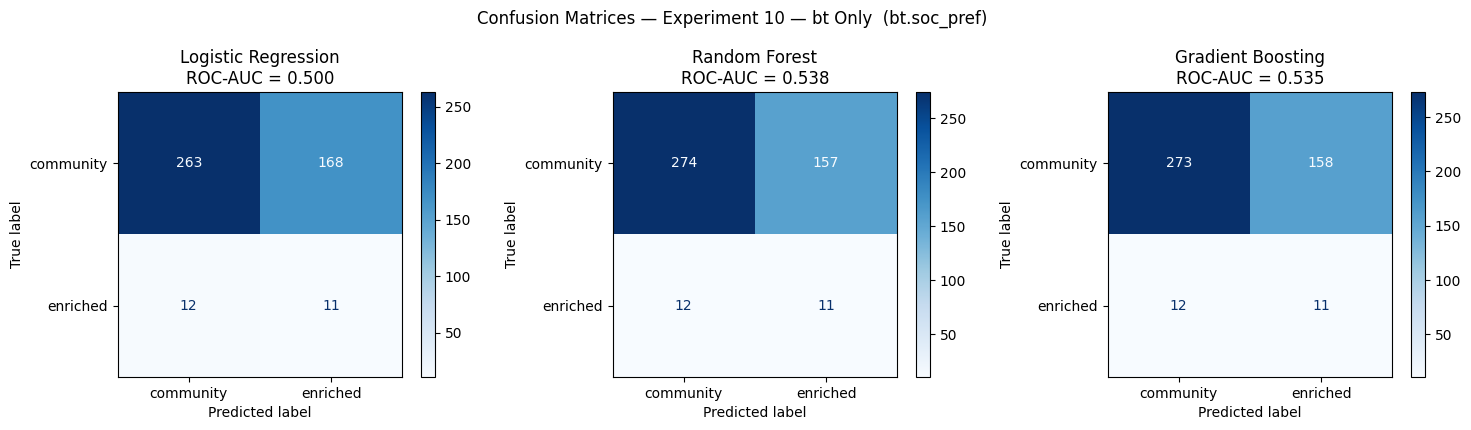


Summary:


,ROC-AUC (test),CV ROC-AUC,Enriched Precision,Enriched Recall,Enriched F1
Logistic Regression,0.5,0.552 ± 0.044,0.061,0.478,0.109
Random Forest,0.538,0.589 ± 0.042,0.065,0.478,0.115
Gradient Boosting,0.535,0.589 ± 0.041,0.065,0.478,0.115


In [39]:
bt_feats2 = [c for c in start_game_cols if c.split('.')[0] == 'bt']
df10 = start[['child_ids'] + bt_feats2].merge(bhisma, on='child_ids')
feat10 = bt_feats2
print(f'Features: {feat10}')
summary10, fitted10, Xte10, yte10 = run_experiment(df10, feat10, 'Experiment 10 — bt Only  (bt.soc_pref)')
print('\nSummary:')
summary10

---
## Experiment 11 — `bpt` Only

**Features:** `bpt.mean_size`, `bpt.mean_euclid`, `bpt.time_taken`  \
**Population:** children with bpt data (ages 2.5–6).

Features: ['bpt.mean_size', 'bpt.mean_euclid', 'bpt.time_taken']

  Experiment 11 — bpt Only  (bpt.mean_size / bpt.mean_euclid / bpt.time_taken)
  Features : ['bpt.mean_size', 'bpt.mean_euclid', 'bpt.time_taken']
  N = 2,308  |  Enriched = 153 (6.6%)

--- Logistic Regression ---
              precision    recall  f1-score   support

   community       0.97      0.78      0.87       431
    enriched       0.17      0.61      0.27        31

    accuracy                           0.77       462
   macro avg       0.57      0.70      0.57       462
weighted avg       0.91      0.77      0.83       462

  ROC-AUC (test): 0.801  | CV ROC-AUC: 0.802 ± 0.022

--- Random Forest ---
              precision    recall  f1-score   support

   community       0.95      0.87      0.91       431
    enriched       0.19      0.42      0.26        31

    accuracy                           0.84       462
   macro avg       0.57      0.64      0.59       462
weighted avg       0.90      0.84      0.87  

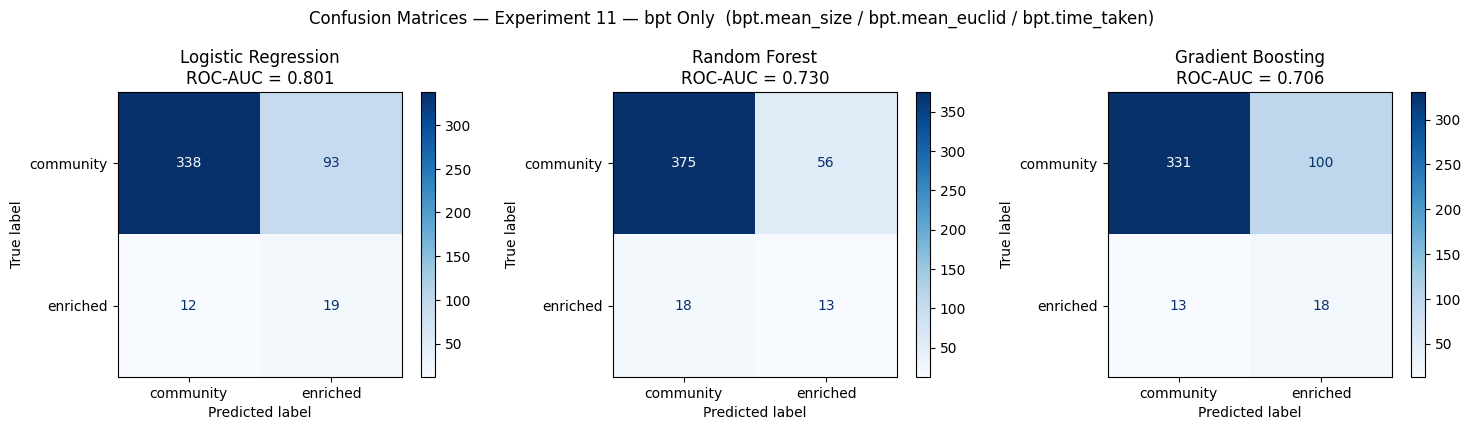


Summary:


,ROC-AUC (test),CV ROC-AUC,Enriched Precision,Enriched Recall,Enriched F1
Logistic Regression,0.801,0.802 ± 0.022,0.17,0.613,0.266
Random Forest,0.73,0.740 ± 0.053,0.188,0.419,0.26
Gradient Boosting,0.706,0.764 ± 0.042,0.153,0.581,0.242


In [40]:
bpt_feats2 = [c for c in start_game_cols if c.split('.')[0] == 'bpt']
df11 = start[['child_ids'] + bpt_feats2].merge(bhisma, on='child_ids')
feat11 = bpt_feats2
print(f'Features: {feat11}')
summary11, fitted11, Xte11, yte11 = run_experiment(df11, feat11, 'Experiment 11 — bpt Only  (bpt.mean_size / bpt.mean_euclid / bpt.time_taken)')
print('\nSummary:')
summary11

---
## Threshold Optimisation — `wt` Experiments

Varying the decision threshold to trade precision for recall.
Targets: recall $\geq$ 0.70, 0.80, 0.90 on the enriched class.
Applied to the best model in each wt experiment:
- **Exp 6** (MDAT+DEEP+wt): RF (ROC-AUC 0.970)
- **Exp 9** (wt only): LR (ROC-AUC 0.790)

In [47]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def threshold_sweep(pipe, X_te, y_te, model_name, exp_name, recall_targets=(0.70, 0.80, 0.9, 0.95)):
    prob = pipe.predict_proba(X_te)[:, 1]
    prec_arr, rec_arr, thr_arr = precision_recall_curve(y_te, prob)
    f1_arr = 2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1] + 1e-8)
    ap = average_precision_score(y_te, prob)

    # Build results table
    rows = []

    # Default threshold 0.5
    pred_def = pipe.predict(X_te)
    from sklearn.metrics import classification_report
    rep_def = classification_report(y_te, pred_def, output_dict=True)
    rows.append({
        'Label': 'Default (t=0.50)',
        'Threshold': 0.50,
        'Precision': round(rep_def['1']['precision'], 3),
        'Recall':    round(rep_def['1']['recall'],    3),
        'F1':        round(rep_def['1']['f1-score'],  3),
        'TP': int(rep_def['1']['recall'] * rep_def['1']['support']),
        'FP': int(round(rep_def['1']['precision'] and
                  (rep_def['1']['recall'] * rep_def['1']['support'] / rep_def['1']['precision']
                   - rep_def['1']['recall'] * rep_def['1']['support']), 0)),
    })

    # Optimal F1
    best_f1_idx = f1_arr.argmax()
    t_f1 = thr_arr[best_f1_idx]
    pred_f1 = (prob >= t_f1).astype(int)
    rep_f1 = classification_report(y_te, pred_f1, output_dict=True)
    rows.append({
        'Label': f'Optimal F1 (t={t_f1:.3f})',
        'Threshold': round(t_f1, 3),
        'Precision': round(rep_f1['1']['precision'], 3),
        'Recall':    round(rep_f1['1']['recall'],    3),
        'F1':        round(rep_f1['1']['f1-score'],  3),
        'TP': int(rep_f1['1']['recall'] * rep_f1['1']['support']),
        'FP': int(round(rep_f1['1']['precision'] and
                  (rep_f1['1']['recall'] * rep_f1['1']['support'] / rep_f1['1']['precision']
                   - rep_f1['1']['recall'] * rep_f1['1']['support']), 0)),
    })

    # Recall targets
    for target in recall_targets:
        # Find lowest threshold where recall >= target
        candidates = [(thr_arr[i], prec_arr[i], rec_arr[i])
                      for i in range(len(thr_arr))
                      if rec_arr[i] >= target]
        if not candidates:
            continue
        # Among those, pick the one with highest precision (highest threshold)
        t_tgt, p_tgt, r_tgt = max(candidates, key=lambda x: x[0])
        pred_tgt = (prob >= t_tgt).astype(int)
        rep_tgt = classification_report(y_te, pred_tgt, output_dict=True)
        rows.append({
            'Label': f'Recall≥{target:.2f} (t={t_tgt:.3f})',
            'Threshold': round(t_tgt, 3),
            'Precision': round(rep_tgt['1']['precision'], 3),
            'Recall':    round(rep_tgt['1']['recall'],    3),
            'F1':        round(rep_tgt['1']['f1-score'],  3),
            'TP': int(rep_tgt['1']['recall'] * rep_tgt['1']['support']),
            'FP': int(round(rep_tgt['1']['precision'] and
                      (rep_tgt['1']['recall'] * rep_tgt['1']['support'] / rep_tgt['1']['precision']
                       - rep_tgt['1']['recall'] * rep_tgt['1']['support']), 0)),
        })

    result_df = pd.DataFrame(rows).set_index('Label')
    n_enriched = int(y_te.sum())

    print(f"\n{'='*60}")
    print(f"  {exp_name}  |  {model_name}")
    print(f"  Test enriched: {n_enriched}  |  AP = {ap:.3f}")
    print(f"{'='*60}")
    print(result_df[['Threshold','Precision','Recall','F1','TP','FP']].to_string())

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # PR curve
    ax = axes[0]
    ax.plot(rec_arr, prec_arr, color='darkorange', lw=2, label=f'AP = {ap:.3f}')
    ax.axhline(n_enriched / len(y_te), color='gray', linestyle='--', alpha=0.6, label='Baseline')
    colors_pts = ['black', 'green', 'blue', 'red', 'purple']
    markers = ['o', '*', 's', '^', 'D']
    for (lbl, row_), c, m in zip(result_df.iterrows(), colors_pts, markers):
        ax.scatter(row_['Recall'], row_['Precision'], s=120, color=c, zorder=5,
                   marker=m, label=lbl)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'PR Curve — {exp_name}\n{model_name}')
    ax.legend(fontsize=7, loc='upper right')

    # Bar chart: precision / recall / F1 per threshold
    ax2 = axes[1]
    x = np.arange(len(result_df))
    width = 0.25
    ax2.bar(x - width, result_df['Precision'], width, label='Precision', color='steelblue',  edgecolor='black')
    ax2.bar(x,         result_df['Recall'],    width, label='Recall',    color='coral',      edgecolor='black')
    ax2.bar(x + width, result_df['F1'],         width, label='F1',        color='mediumseagreen', edgecolor='black')
    ax2.set_xticks(x)
    ax2.set_xticklabels(result_df.index, rotation=15, ha='right', fontsize=8)
    ax2.set_ylim(0, 1)
    ax2.set_title('Enriched-class metrics at each threshold')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    return result_df

print("Threshold sweep helper loaded.")

Threshold sweep helper loaded.


### Experiment 6 — MDAT + DEEP + `wt`  (RF)


  Exp 6 — MDAT+DEEP+wt  |  Random Forest
  Test enriched: 67  |  AP = 0.929
                       Threshold  Precision  Recall     F1  TP   FP
Label                                                              
Default (t=0.50)           0.500      0.838   0.851  0.844  57   11
Optimal F1 (t=0.727)       0.727      0.949   0.836  0.889  56    3
Recall≥0.70 (t=1.000)      1.000      1.000   0.746  0.855  50    0
Recall≥0.80 (t=0.823)      0.823      0.947   0.806  0.871  54    3
Recall≥0.90 (t=0.400)      0.400      0.762   0.910  0.830  61   19
Recall≥0.95 (t=0.127)      0.127      0.346   0.955  0.508  64  121


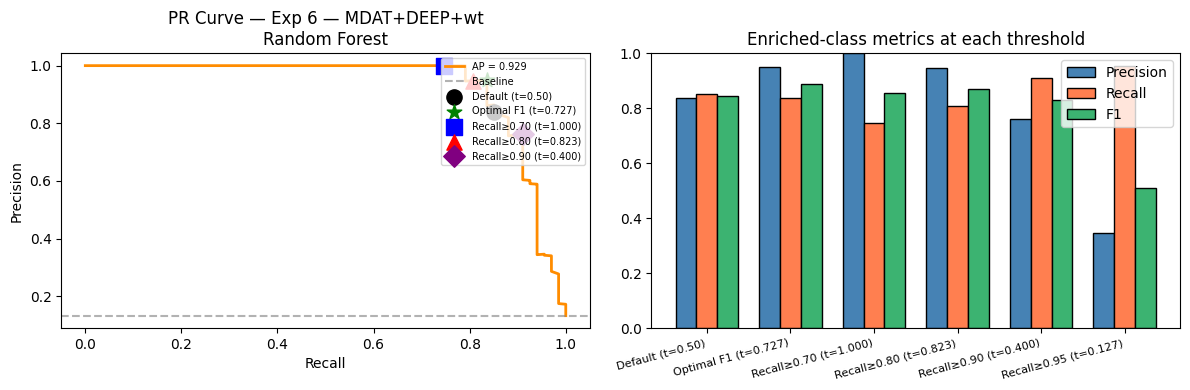

In [48]:
thres6 = threshold_sweep(
    fitted6['Random Forest'], Xte6, yte6,
    model_name='Random Forest',
    exp_name='Exp 6 — MDAT+DEEP+wt'
)

### Experiment 9 — `wt` Only  (LR)


  Exp 9 — wt only  |  Logistic Regression
  Test enriched: 26  |  AP = 0.337
                       Threshold  Precision  Recall     F1  TP   FP
Label                                                              
Default (t=0.50)           0.500      0.125   0.731  0.213  19  133
Optimal F1 (t=0.714)       0.714      0.324   0.462  0.381  12   25
Recall≥0.70 (t=0.515)      0.515      0.137   0.731  0.230  19  120
Recall≥0.80 (t=0.447)      0.447      0.102   0.808  0.182  21  184
Recall≥0.90 (t=0.365)      0.365      0.086   0.923  0.157  24  255
Recall≥0.95 (t=0.340)      0.340      0.083   0.962  0.153  25  276


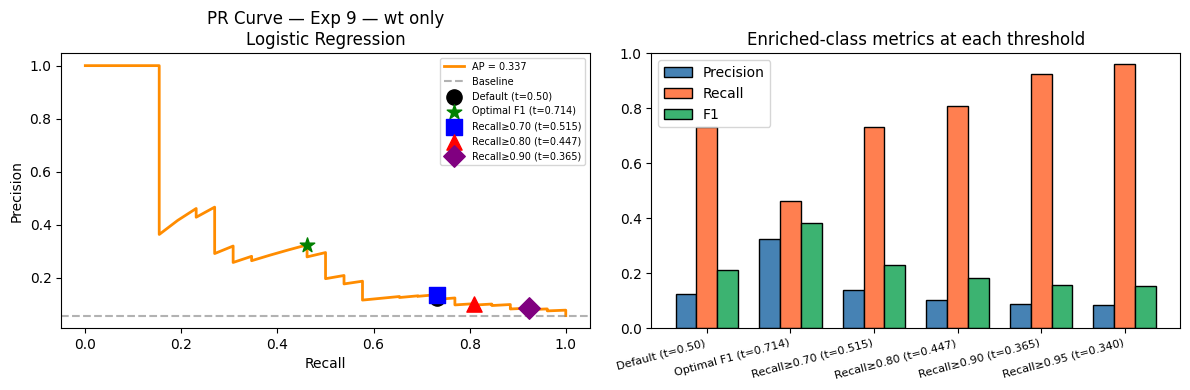

In [49]:
thres9 = threshold_sweep(
    fitted9['Logistic Regression'], Xte9, yte9,
    model_name='Logistic Regression',
    exp_name='Exp 9 — wt only'
)

### Experiment 9 — `wt` Only: Youden's J Optimal Threshold

Youden's J = Sensitivity + Specificity − 1 = TPR − FPR.
Maximising J finds the ROC-curve point furthest from the random-chance diagonal.

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, ConfusionMatrixDisplay

pipe9_lr = fitted9['Logistic Regression']
prob9    = pipe9_lr.predict_proba(Xte9)[:, 1]

fpr, tpr, thresholds = roc_curve(yte9, prob9)
J        = tpr - fpr                         # Youden's J for every threshold
best_idx = J.argmax()
t_youden = thresholds[best_idx]

print(f"Youden's J statistic:  {J[best_idx]:.4f}")
print(f"Optimal threshold:     {t_youden:.4f}")
print(f"  Sensitivity (TPR):   {tpr[best_idx]:.4f}")
print(f"  Specificity (TNR):   {1 - fpr[best_idx]:.4f}")
print(f"  FPR:                 {fpr[best_idx]:.4f}")

# Apply threshold
y_pred_youden = (prob9 >= t_youden).astype(int)

print(f"\n--- Classification report at Youden threshold (t = {t_youden:.3f}) ---")
print(classification_report(yte9, y_pred_youden, target_names=['community', 'enriched']))
print(f"ROC-AUC: {roc_auc_score(yte9, prob9):.3f}")

# --- comparison table ---
rows = {}
for label, pred in [
    ('Default  (t = 0.500)',        pipe9_lr.predict(Xte9)),
    (f'Youden J (t = {t_youden:.3f})', y_pred_youden),
]:
    rep = classification_report(pred_true := yte9, pred, output_dict=True)
    rows[label] = {
        'Threshold':  float(label.split('t = ')[1].rstrip(')')),
        'Precision':  round(rep['1']['precision'], 3),
        'Recall':     round(rep['1']['recall'],    3),
        'F1':         round(rep['1']['f1-score'],  3),
        'Specificity': round(1 - fpr[best_idx] if 'Youden' in label else
                       (yte9 == 0).sum() / len(yte9) * 0 +
                       (y_pred_youden == 0)[yte9 == 0].mean()
                       if 'Youden' in label else
                       pipe9_lr.predict(Xte9)[yte9==0].tolist().count(0) / (yte9==0).sum(), 3),
    }

# Simpler comparison
from sklearn.metrics import confusion_matrix
print("\n=== Comparison ===")
for label, pred in [
    ('Default  (t=0.500)',        pipe9_lr.predict(Xte9)),
    (f'Youden J (t={t_youden:.3f})', y_pred_youden),
]:
    tn, fp, fn, tp = confusion_matrix(yte9, pred).ravel()
    p  = tp / (tp + fp) if (tp+fp) else 0
    r  = tp / (tp + fn) if (tp+fn) else 0
    f1 = 2*p*r / (p+r) if (p+r) else 0
    spec = tn / (tn + fp)
    print(f"{label}")
    print(f"  Precision={p:.3f}  Recall={r:.3f}  F1={f1:.3f}  Specificity={spec:.3f}  TP={tp}  FP={fp}  FN={fn}  TN={tn}")

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ROC curve with Youden point
ax = axes[0]
ax.plot(fpr, tpr, color='darkorange', lw=2,
        label=f'ROC (AUC = {roc_auc_score(yte9, prob9):.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.scatter(fpr[best_idx], tpr[best_idx], s=180, color='red', zorder=5,
           label=f"Youden's J = {J[best_idx]:.3f}\n(t = {t_youden:.3f})")
ax.set_xlabel('FPR  (1 − Specificity)')
ax.set_ylabel('TPR  (Sensitivity / Recall)')
ax.set_title("ROC Curve — Exp 9 (wt only, LR)")
ax.legend(fontsize=8)

# J statistic vs threshold
ax2 = axes[1]
ax2.plot(thresholds, J, color='steelblue', lw=2)
ax2.axvline(t_youden, color='red', linestyle='--', label=f't = {t_youden:.3f}')
ax2.scatter([t_youden], [J[best_idx]], s=120, color='red', zorder=5)
ax2.set_xlabel("Threshold")
ax2.set_ylabel("Youden's J  (TPR − FPR)")
ax2.set_title("Youden's J vs Threshold")
ax2.legend()

# Confusion matrix
ax3 = axes[2]
ConfusionMatrixDisplay.from_predictions(
    yte9, y_pred_youden,
    display_labels=['community', 'enriched'],
    ax=ax3, cmap='Blues'
)
ax3.set_title(f"Confusion Matrix\nYouden threshold (t = {t_youden:.3f})")

plt.tight_layout()
plt.show()

### Side-by-side summary

In [44]:
print("Exp 6 (MDAT+DEEP+wt  RF):")
print(thres6[['Threshold','Precision','Recall','F1']].to_string())
print()
print("Exp 9 (wt only  LR):")
print(thres9[['Threshold','Precision','Recall','F1']].to_string())

Exp 6 (MDAT+DEEP+wt  RF):
                       Threshold  Precision  Recall     F1
Label                                                     
Default (t=0.50)           0.500      0.838   0.851  0.844
Optimal F1 (t=0.727)       0.727      0.949   0.836  0.889
Recall≥0.70 (t=1.000)      1.000      1.000   0.746  0.855
Recall≥0.80 (t=0.823)      0.823      0.947   0.806  0.871
Recall≥0.90 (t=0.400)      0.400      0.762   0.910  0.830

Exp 9 (wt only  LR):
                       Threshold  Precision  Recall     F1
Label                                                     
Default (t=0.50)           0.500      0.125   0.731  0.213
Optimal F1 (t=0.714)       0.714      0.324   0.462  0.381
Recall≥0.70 (t=0.515)      0.515      0.137   0.731  0.230
Recall≥0.80 (t=0.447)      0.447      0.102   0.808  0.182
Recall≥0.90 (t=0.365)      0.365      0.086   0.923  0.157


---
## Cross-Experiment Comparison

All experiments side-by-side. **Exp 4 is the MDAT+DEEP anchor** — differences vs Exp 4
show the marginal contribution of each START game.

In [45]:
baseline = pd.DataFrame({
    'Logistic Regression': {'ROC-AUC (test)': 0.767, 'CV ROC-AUC': '0.774 ± 0.049',
                            'Enriched Precision': 0.075, 'Enriched Recall': 0.615, 'Enriched F1': 0.134},
    'Random Forest':       {'ROC-AUC (test)': 0.785, 'CV ROC-AUC': '0.754 ± 0.049',
                            'Enriched Precision': 0.100, 'Enriched Recall': 0.154, 'Enriched F1': 0.121},
    'Gradient Boosting':   {'ROC-AUC (test)': 0.715, 'CV ROC-AUC': '0.696 ± 0.075',
                            'Enriched Precision': 0.139, 'Enriched Recall': 0.385, 'Enriched F1': 0.204},
}).T

def tag(df, label):
    d = df.copy()
    d.index = [f"{label}  |  {m}" for m in d.index]
    return d

all_results = pd.concat([
    tag(baseline,   'Baseline  (START all games)'),
    tag(summary1,   'Exp 1   (MDAT tot)'),
    tag(summary2,   'Exp 2   (DEEP tot)'),
    tag(summary3,   f'Exp 3   (MDAT+DEEP+{best_game})'),
    tag(summary4,   'Exp 4   (MDAT+DEEP)'),
    tag(summary5,   'Exp 5   (MDAT+DEEP+bt)'),
    tag(summary6,   'Exp 6   (MDAT+DEEP+wt)'),
    tag(summary7,   'Exp 7   (MDAT+DEEP+bpt)'),
    tag(summary8,   'Exp 8   (dgt only)'),
    tag(summary9,   'Exp 9   (wt only)'),
    tag(summary10,  'Exp 10  (bt only)'),
    tag(summary11,  'Exp 11  (bpt only)'),
])

print(all_results.to_string())
all_results

                                                    ROC-AUC (test)     CV ROC-AUC Enriched Precision Enriched Recall Enriched F1
Baseline  (START all games)  |  Logistic Regression          0.767  0.774 ± 0.049              0.075           0.615       0.134
Baseline  (START all games)  |  Random Forest                0.785  0.754 ± 0.049                0.1           0.154       0.121
Baseline  (START all games)  |  Gradient Boosting            0.715  0.696 ± 0.075              0.139           0.385       0.204
Exp 1   (MDAT tot)  |  Logistic Regression                    0.62  0.582 ± 0.016              0.168           0.604       0.263
Exp 1   (MDAT tot)  |  Random Forest                         0.826  0.798 ± 0.023              0.286           0.713       0.408
Exp 1   (MDAT tot)  |  Gradient Boosting                     0.875  0.845 ± 0.018              0.409           0.713        0.52
Exp 2   (DEEP tot)  |  Logistic Regression                   0.874  0.813 ± 0.032              0.

,ROC-AUC (test),CV ROC-AUC,Enriched Precision,Enriched Recall,Enriched F1
Baseline (START all games) | Logistic Regression,0.767,0.774 ± 0.049,0.075,0.615,0.134
Baseline (START all games) | Random Forest,0.785,0.754 ± 0.049,0.1,0.154,0.121
Baseline (START all games) | Gradient Boosting,0.715,0.696 ± 0.075,0.139,0.385,0.204
Exp 1 (MDAT tot) | Logistic Regression,0.62,0.582 ± 0.016,0.168,0.604,0.263
Exp 1 (MDAT tot) | Random Forest,0.826,0.798 ± 0.023,0.286,0.713,0.408
Exp 1 (MDAT tot) | Gradient Boosting,0.875,0.845 ± 0.018,0.409,0.713,0.52
Exp 2 (DEEP tot) | Logistic Regression,0.874,0.813 ± 0.032,0.189,0.8,0.306
Exp 2 (DEEP tot) | Random Forest,0.666,0.702 ± 0.054,0.11,0.5,0.181
Exp 2 (DEEP tot) | Gradient Boosting,0.747,0.772 ± 0.047,0.221,0.633,0.328
Exp 3 (MDAT+DEEP+dgt) | Logistic Regression,0.8,0.818 ± 0.029,0.29,0.628,0.397


### ROC-AUC Bar Chart — All Experiments

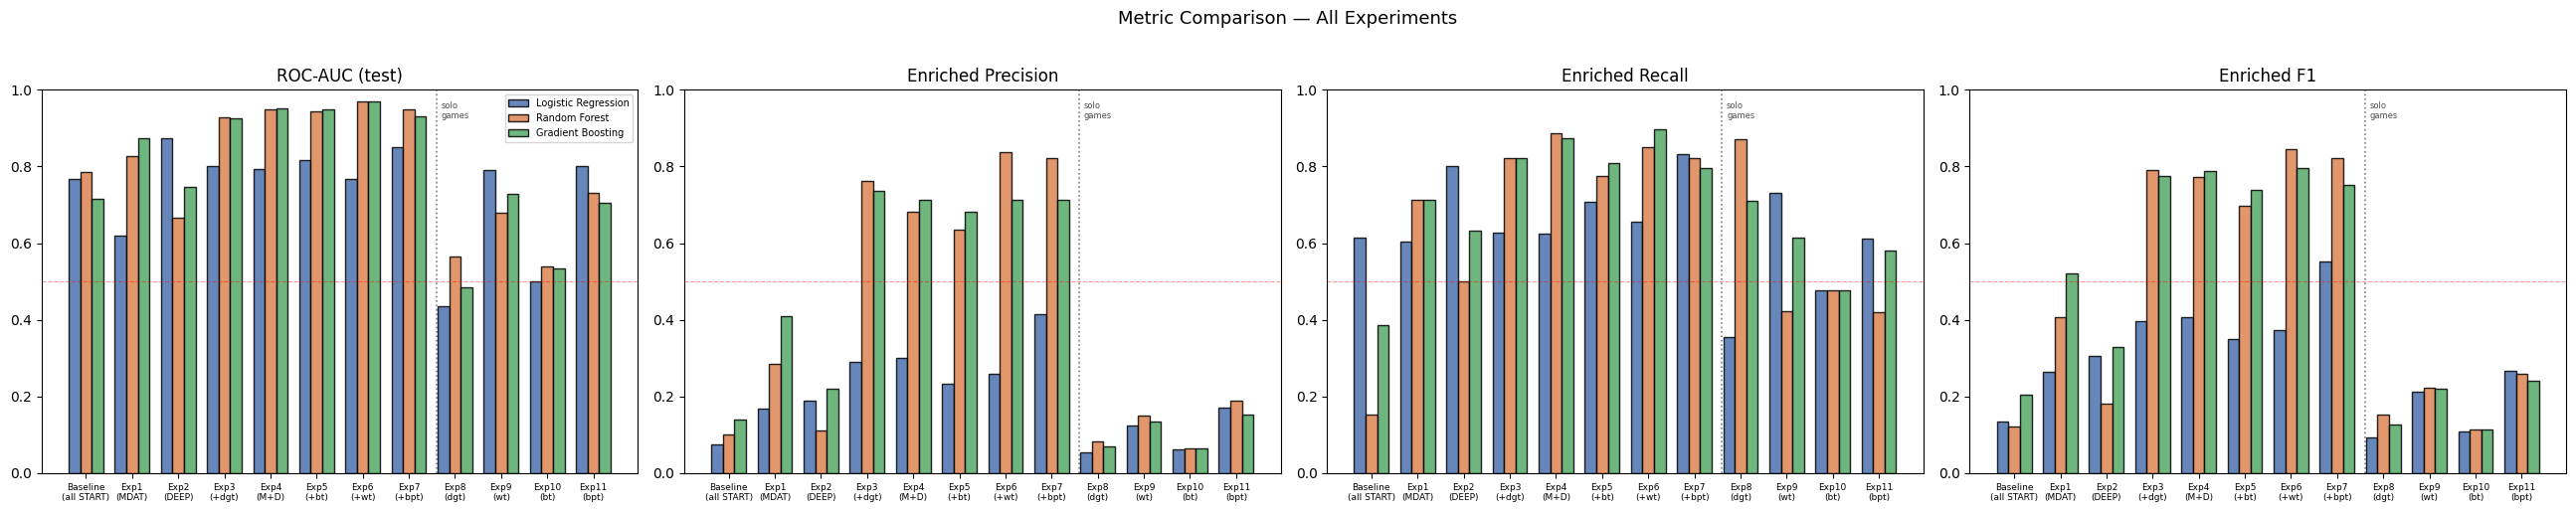

In [46]:
numeric_cols = ['ROC-AUC (test)', 'Enriched Precision', 'Enriched Recall', 'Enriched F1']

models    = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']
summaries = [baseline, summary1, summary2, summary3, summary4,
             summary5, summary6, summary7, summary8, summary9, summary10, summary11]
exp_labels = [
    'Baseline\n(all START)', 'Exp1\n(MDAT)', 'Exp2\n(DEEP)',
    'Exp3\n(+dgt)', 'Exp4\n(M+D)',
    'Exp5\n(+bt)', 'Exp6\n(+wt)', 'Exp7\n(+bpt)',
    'Exp8\n(dgt)', 'Exp9\n(wt)', 'Exp10\n(bt)', 'Exp11\n(bpt)',
]

fig, axes = plt.subplots(1, 4, figsize=(26, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, metric in zip(axes, numeric_cols):
    data = {m: [] for m in models}
    for summ in summaries:
        for model in models:
            val = pd.to_numeric(summ.loc[model, metric], errors='coerce') if model in summ.index else float('nan')
            data[model].append(val)
    x = np.arange(len(exp_labels))
    width = 0.25
    for i, (model, vals) in enumerate(data.items()):
        ax.bar(x + i*width, vals, width, label=model, color=colors[i], edgecolor='black', alpha=0.85)
    ax.set_xticks(x + width)
    ax.set_xticklabels(exp_labels, fontsize=6.5)
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color='red', linestyle='--', alpha=0.4, linewidth=0.8)
    # dividers
    ax.axvline(7.85, color='black', linestyle=':', alpha=0.5, linewidth=1.2)
    ax.text(7.95, 0.97, 'solo\ngames', fontsize=6, va='top', color='black', alpha=0.7)
    if ax == axes[0]:
        ax.legend(fontsize=7)

plt.suptitle('Metric Comparison — All Experiments', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()